# Goolge Elevation
This notebook is used to extract the elevation from the Goolge Elevation API for each waypoint of an hikingroute. We get the waypoints stored azure cloud and query the API for its elevations. 

As the waypoints of the hikingroutes are not sortet we transform the data in order to be able to plot elevation profiles and calculate distances. We use an heuristic formula close to the Traveling Salesman Problem. 

In [1]:
import requests
import json
import pymssql
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from scipy.spatial.distance import cdist
from math import radians, sin, cos, sqrt, atan2
from sqlalchemy import Integer, String, Float, DATETIME, create_engine

### Retrieve all the waypoints

In [2]:
# Load configuration from config/db_config.json
with open('../config/db_config.json', 'r') as f:
    db_config = json.load(f)

# Get database credentials
server = db_config['server']
database = db_config['database']
db_user = db_config['db_user']
db_password = db_config['db_password']# Connect to SQL Database
conn = pymssql.connect(server, db_user, db_password, database)

# Create connection string for SQLAlchemy
connection_string = f"mssql+pymssql://{db_user}:{db_password}@{server}/{database}"
engine = create_engine(connection_string)

# SQL query to retrieve waypoints
query = "SELECT ID, LAT, LON FROM OVRP_waypoints"

# Load data into DataFrame
waypoints = pd.read_sql_query(query, con=engine)

print(waypoints.head(3))

         ID        LAT       LON
0  28022787  46.871293  6.581740
1  28022788  46.874111  6.589236
2  28022789  46.878365  6.598630


### Send the request to the google API and retrieve the elevation for each waypoint

In [ ]:
# Load goolge api key 
with open("../config/api_config.json", 'r') as f:
    api_config = json.load(f)

api_key = api_config["api_key_google_maps"]

# Empty list to store the results
results = []

# Iterate over the waypoints DataFrame
for index, row in waypoints.iterrows():
    latitude = row["LAT"]
    longitude = row["LON"]
    waypoint_id = row["ID"]

    # API-Request
    url = f"https://maps.googleapis.com/maps/api/elevation/json"
    params = {
        "locations": f"{latitude},{longitude}",
        "key": api_key
    }

    try:
        response = requests.get(url, params=params)
        response.raise_for_status()
        data = response.json()

        # Extract elevation
        elevation = data["results"][0]["elevation"]

        # Append the result
        results.append({
            "id": waypoint_id,
            "latitude": latitude,
            "longitude": longitude,
            "elevation": elevation
        })

    except (requests.exceptions.RequestException, KeyError, IndexError) as e:
        print(f"Fehler für ID {waypoint_id}: {e}")
        results.append({
            "id": waypoint_id,
            "latitude": latitude,
            "longitude": longitude,
            "elevation": None
        })

# transform the results in a data Frame
result_df = pd.DataFrame(results)

# show the results
print(result_df)

                id   latitude  longitude    elevation
0       28022787.0  46.871293   6.581740  1390.655518
1       28022788.0  46.874111   6.589236  1291.659546
2       28022789.0  46.878365   6.598630  1194.116821
3       33636662.0  46.867863   6.573559  1421.337280
4       36789486.0  46.880193   6.612009  1263.661255
...            ...        ...        ...          ...
31760  497874972.0  47.713981   8.889910   419.983826
31761  497874993.0  47.711298   8.889283   440.823212
31762  497874994.0  47.713006   8.889728   424.057678
31763  497874995.0  47.710600   8.888011   455.662384
31764  497874996.0  47.709732   8.886718   494.598450

[31765 rows x 4 columns]


### Store the data in a tempory table on azure cloud

In [ ]:
# Create table if it doesn't exist
table_name = "Google_Elevation"
query = f"""
    IF OBJECT_ID(N'dbo.{table_name}', N'U') IS NULL
    BEGIN
        CREATE TABLE {table_name} (
            id                      INT         NOT NULL PRIMARY KEY,
            lat                     FLOAT       NOT NULL,
            lon                     FLOAT       NOT NULL,
            elevation               FLOAT       NOT NULL,
            timestamp_apicall       DATETIME    NULL
        );
    END
    """

conn = pymssql.connect(server, db_user, db_password, database)
cursor = conn.cursor()
cursor.execute(query)

conn.commit()
conn.close()

In [16]:
table_name = "Google_Elevation"

# Create connection string for SQLAlchemy
connection_string = f"mssql+pymssql://{db_user}:{db_password}@{server}/{database}"
engine = create_engine(connection_string)

# Ingest data to tabledatabase table
result_df.to_sql(table_name, con=engine, if_exists='replace', index=False)
print("DataFrame erfolgreich in die MSSQL-Datenbank geladen!")

DataFrame erfolgreich in die MSSQL-Datenbank geladen!


### Retrieve the data from the temporary table

In [10]:
# Load configuration from config/db_config.json
with open('../config/db_config.json', 'r') as f:
    db_config = json.load(f)

# Get database credentials
server = db_config['server']
database = db_config['database']
db_user = db_config['db_user']
db_password = db_config['db_password']# Connect to SQL Database
conn = pymssql.connect(server, db_user, db_password, database)

# Create connection string for SQLAlchemy
connection_string = f"mssql+pymssql://{db_user}:{db_password}@{server}/{database}"
engine = create_engine(connection_string)

# SQL Query
query = "SELECT w.id, w.itshikingroute, w.lat, w.lon, g.elevation From OVRP_waypoints w join Google_Elevation g on w.id = g.id"

# Load data into DataFrame
df_hikingroute = pd.read_sql_query(query, con=engine)

print(df_hikingroute.head(3))

         id  itshikingroute        lat       lon    elevation
0  28022787          120125  46.871293  6.581740  1390.655518
1  28022788          120125  46.874111  6.589236  1291.659546
2  28022789          120125  46.878365  6.598630  1194.116821


### Transform the Data: Sort the waypoints of the hikingroutes

In [11]:
# list to store sorted DataFrames
sorted_dfs = []

# group by hikingroute
for hikingroute, group in df_hikingroute.groupby("itshikingroute"):

    # index reset
    group = group.reset_index(drop=True)
    
    # calculate distance
    coordinates = group[["lat", "lon"]].values
    dist_matrix = cdist(coordinates, coordinates)
    
    # start point based on minimum latitude
    start_index = group["lat"].idxmin()  # Select the index of the minimum latitude
    
    # sorted order  
    visited = [start_index]
    while len(visited) < len(group):
        last = visited[-1]
        next_point = np.argmin(
            [dist_matrix[last][j] if j not in visited else np.inf for j in range(len(dist_matrix))]
        )
        visited.append(next_point)
    
    # df in sorted order
    sorted_group = group.iloc[visited].reset_index(drop=True)
    
    # column sortierung
    sorted_group["sortierung"] = range(1, len(sorted_group) + 1)
    
    # save to list
    sorted_dfs.append(sorted_group)

# concat    
sorted_df_hikingroute = pd.concat(sorted_dfs, ignore_index=True)

# show results
print(sorted_df_hikingroute.head(3))

          id  itshikingroute        lat       lon   elevation  sortierung
0  236852473          120125  46.842100  6.654761  610.750183           1
1  741649277          120125  46.845635  6.654258  707.752380           2
2  311274467          120125  46.850094  6.654447  758.327393           3


### Transform the Data: Calculate the lenght of each hikingroute

In [12]:
# Use haversine formula to calculate distance between two coordinates
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # radius of the earth in kilometers
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat / 2) ** 2 + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    return R * c

# add start and end point and distance column
route_distances = []

for hikingroute, group in sorted_df_hikingroute.groupby("itshikingroute"):
    # define start and end point
    start_point = group.iloc[0]
    end_point = group.iloc[-1]
    
    # calculate distance
    distance = haversine(start_point["lat"], start_point["lon"], end_point["lat"], end_point["lon"])
    
    # add start and end point and distance column
    group["start_lat"] = start_point["lat"]
    group["start_lon"] = start_point["lon"]
    group["end_lat"] = end_point["lat"]
    group["end_lon"] = end_point["lon"]
    group["distance"] = distance
    
    route_distances.append(group)

# grouped dataframes together
extended_df_hikingroute = pd.concat(route_distances, ignore_index=True)

# reduce columns
final_df = extended_df_hikingroute[[
    "id", "itshikingroute", "lat", "lon", "sortierung", "distance"
]].copy()

# add timestamp
final_df["timestamp_apicall"] = pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S")

print(final_df.head(3))


          id  itshikingroute        lat       lon  sortierung  distance  \
0  236852473          120125  46.842100  6.654761           1  6.806788   
1  741649277          120125  46.845635  6.654258           2  6.806788   
2  311274467          120125  46.850094  6.654447           3  6.806788   

     timestamp_apicall  
0  2024-12-10 22:56:00  
1  2024-12-10 22:56:00  
2  2024-12-10 22:56:00  


### Plot elevation profile for a specific hikingroute

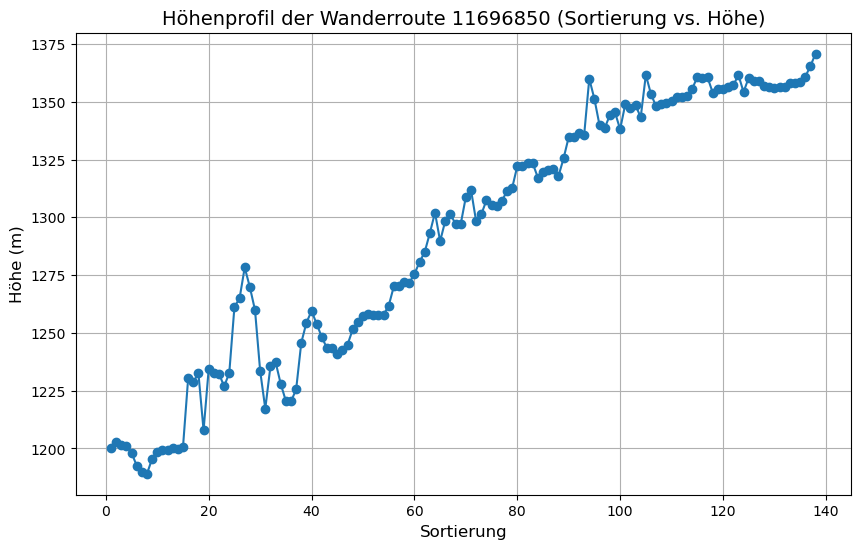

In [13]:
# select a specific hiking route
selected_route = extended_df_hikingroute[
    extended_df_hikingroute["itshikingroute"] == 11696850
].reset_index(drop=True)

# plot it
plt.figure(figsize=(10, 6))
plt.plot(selected_route["sortierung"], selected_route["elevation"], marker="o", linestyle="-")

# set labels and title
plt.title("Höhenprofil der Wanderroute 11696850 (Sortierung vs. Höhe)", fontsize=14)
plt.xlabel("Sortierung", fontsize=12)
plt.ylabel("Höhe (m)", fontsize=12)
plt.grid(True)

# Plot anzeigen
plt.show()

### Store the data in Google_Elevation_Distancece table on azure cloud

In [14]:
table_name = "Google_Elevation_Distance"

# Create table if it doesn't exist
query = f"""
        CREATE TABLE {table_name} (
            id                      INT         NOT NULL,
            itshikingroute          INT         NOT NULL,
            lat                     FLOAT       NOT NULL,
            lon                     FLOAT       NOT NULL,
            sortierung              INT         NOT NULL,
            distance                FLOAT       NOT NULL,
            timestamp_apicall       DATETIME    NULL,
            FOREIGN KEY (itshikingroute) REFERENCES OVRP_HikingRoutes (id)
        );
    """

conn = pymssql.connect(server, db_user, db_password, database)
cursor = conn.cursor()
cursor.execute(query)

conn.commit()
conn.close()

In [15]:
# Create connection string for SQLAlchemy
connection_string = f"mssql+pymssql://{db_user}:{db_password}@{server}/{database}"
engine = create_engine(connection_string)

# Ingest data to tabledatabase table
final_df.to_sql(table_name, con=engine, if_exists='append', index=False)
print("DataFrame erfolgreich in die MSSQL-Datenbank geladen!")

DataFrame erfolgreich in die MSSQL-Datenbank geladen!
